In [ ]:
'''
Because of the sheer size of the datasets, the script was only allowed to 
run for enough time to populate the "fake" and "real" folders in the train dataset with approx. 300-500 MB of images each.
'''

import os
from tqdm import tqdm
from datasets import load_dataset
from modelscope.msdatasets import MsDataset


def download_split_openfake(split_name, base_dir):
    print(f"\n Downloading OpenFake '{split_name}' split images")
    dataset = load_dataset("ComplexDataLab/OpenFake", split=split_name, streaming=True)

    # Output folders
    real_dir = os.path.join(base_dir, split_name, "real")
    fake_dir = os.path.join(base_dir, split_name, "fake")
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset, desc=f"Processing {split_name} split")):
        image = sample["image"]
        label = sample["label"]  # 'real' or 'fake'

        # Convert any non-RGB image to RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Choose path based on real or fake
        subdir = real_dir if label == "real" else fake_dir
        image_path = os.path.join(subdir, f"{split_name}_{i:07d}.jpg")

        image.save(image_path)

    print(f"Finished {split_name} split: saved to {os.path.join(base_dir, split_name)}")


def import_openfake():
    base_dir="datasets/OpenFake"

    paths = [
            os.path.join(base_dir, "train", "real"),
            os.path.join(base_dir, "train", "fake"),
            os.path.join(base_dir, "test", "real"),
            os.path.join(base_dir, "test", "fake"),
        ]

    for path in paths:
        os.makedirs(path, exist_ok=True)

    download_split_openfake("train", base_dir)
    download_split_openfake("test", base_dir)

    print("\n Done. Dataset organized in:")
    print(os.path.abspath(base_dir))

def download_split_wildfake(split_name, base_dir):
    print(f"\n Downloading Wildfake '{split_name}' split images")
    dataset = MsDataset.load('hy2628982280/WildFake', subset_name='default', split=split_name)

    # Output folders
    real_dir = os.path.join(base_dir, split_name, "real")
    fake_dir = os.path.join(base_dir, split_name, "fake")
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset, desc=f"Processing {split_name} split")):
        image = sample["image"]
        label = sample["IsFake"]  # 0 = real, 1 = fake (based on dataset card)


        # Convert RGBA to RGB to avoid JPEG errors
        if image.mode == "RGBA":
            image = image.convert("RGB")

        # Choose path based on real or fake
        subdir = real_dir if label == 0 else fake_dir
        image_path = os.path.join(subdir, f"{split_name}_{i:07d}.jpg")

        image.save(image_path)

    print(f"Finished {split_name} split: saved to {os.path.join(base_dir, split_name)}")

def import_wildfake():
    base_dir="datasets/WildFake"

    paths = [
            os.path.join(base_dir, "train", "real"),
            os.path.join(base_dir, "train", "fake"),
            os.path.join(base_dir, "test", "real"),
            os.path.join(base_dir, "test", "fake"),
        ]

    for path in paths:
        os.makedirs(path, exist_ok=True)

    download_split_wildfake('train', base_dir)
    download_split_wildfake('test', base_dir)
    print("\nDone. Dataset organized in:")
    print(os.path.abspath(base_dir))

def download_split_dragon(dataset_split, split_name, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset_split, desc=f"Processing {split_name}")):

        # Images are stored under png
        image = sample["png"]
        if image.mode == "RGBA":
            image = image.convert("RGB")

        filename = f"{split_name}_{i:07d}.jpg"
        image.save(os.path.join(out_dir, filename))

def import_dragon():
    base_dir = 'datasets/DRAGON'
    size_split = "ExtraLarge"
    print(f"Downloading DRAGON ({size_split}) subset")
    ds = load_dataset("lesc-unifi/dragon", size_split)

    # Create output directories
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    download_split_dragon(ds["train"], "train", train_dir)
    download_split_dragon(ds["test"], "test", test_dir)

    print(f"Done. DRAGON ({size_split}) saved in {os.path.abspath(base_dir)}")


def main():
    import_openfake()
    import_wildfake()
    import_dragon()

    return 0


if __name__ == "__main__":
    main()

Resolving data files:   0%|          | 0/526 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/526 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Processing train split: 5608it [05:00, 25.99it/s]c:\Users\zuhai\anaconda3\envs\deepfake\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Processing train split: 8897it [08:42, 17.03it/s]


KeyboardInterrupt: 

## Evaluate Baseline Model

In [19]:
from timm import create_model
import torch.nn as nn

model = create_model("vit_base_patch16_224.orig_in21k", pretrained=True)

# Get the number of input features to the final layer 
num_ftrs = model.num_features 

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2) 

model.eval()
print(model)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
import os
import random

train_dir = 'datasets/OpenFake/train'
real_dir = os.path.join(train_dir, 'real')
fake_dir = os.path.join(train_dir, 'fake')

num_images = 1000

real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

selected_real_images = random.sample(real_images, num_images)
selected_fake_images = random.sample(fake_images, num_images)

# Combine them into a list of selected images with their labels
selected_images = selected_real_images + selected_fake_images
labels = [0] * num_images + [1] * num_images  


In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class OpenFakeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB") 
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),    # Resize to match ViT's input size
    transforms.ToTensor(),            # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats that the ViT was trained on
])


dataset = OpenFakeDataset(selected_images, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


100%|██████████| 125/125 [05:15<00:00,  2.53s/it]


Accuracy: 48.65%
Sensitivity (Recall): 0.58
Specificity: 0.40
Positive Predictive Value (PPV): 0.49
Negative Predictive Value (NPV): 0.48
Average Loss: 0.6981

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.40      0.44      1000
           1       0.49      0.58      0.53      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.48      2000
weighted avg       0.49      0.49      0.48      2000



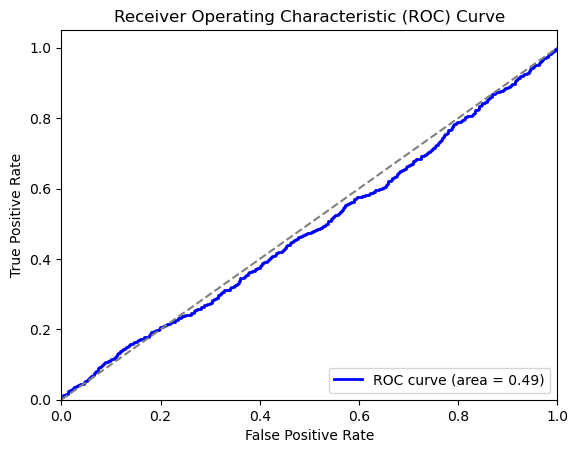

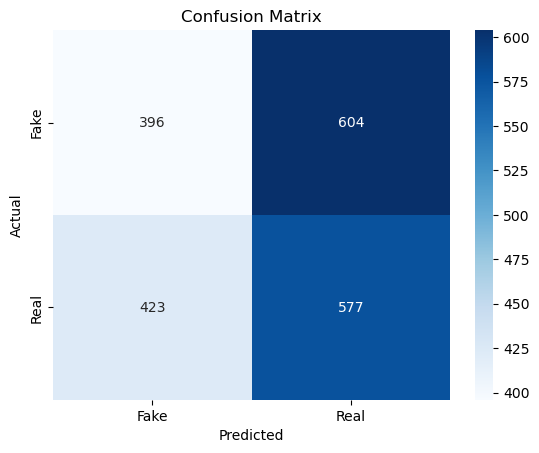

In [ ]:
import torch
import numpy as np
from torch import nn
from tqdm import tqdm  # For progress bar
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# loss function (binary cross-entropy for binary classification)
criterion = nn.CrossEntropyLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

all_preds = []
all_labels = []
all_probs = []  # hold the probabilities for the ROC curve
running_loss = 0.0

with torch.no_grad():  # No need to track gradients for evaluation
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and labels (for metrics calculation)
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Store predicted probabilities for ROC curve
        probs = torch.softmax(outputs, dim=1)  
        all_probs.append(probs.cpu().numpy()[:, 1])  # Store probs for class 1 (real/fake)

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

# Additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) 
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)  
npv = tn / (tn + fn)  

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs) 
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {running_loss / len(dataloader):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Plot ROC
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


## Create and train model with specialized deepfake detection layers

In [ ]:
import os
import random
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from PIL import Image
from timm import create_model
import numpy as np
from tqdm import tqdm  # For progress bar
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

class DeepfakeDetectionViT(nn.Module):
    def __init__(self, pretrained=True):
        super(DeepfakeDetectionViT, self).__init__()
        
        # Load the ViT base model
        self.vit = create_model("vit_base_patch16_224.orig_in21k", pretrained=pretrained)
        
        num_ftrs = self.vit.num_features
        
        # Custom fully connected layers for deepfake detection
        self.fc1 = nn.Linear(num_ftrs, 512)  # fully connected layer
        self.fc2 = nn.Linear(512, 2)  # output for real/fake detection (2 classes)
        self.relu = nn.ReLU()  # activation function
    
    def forward(self, x):
        # Pass through ViT model for feature extraction
        x = self.vit.forward_features(x)  
        
        # Extract the class token (first token) 
        x = x[:, 0, :] 
        
        # Pass through the fully connected layers
        x = self.fc1(x)
        x = self.relu(x)  # apply non-linear ReLU activation
        x = self.fc2(x)  # output layer 
        
        return x


In [ ]:
# Dataset class to follow PyTorch conventions
class OpenFakeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [ ]:
# Data preparation + augmentation
train_dir = 'datasets/OpenFake/train'
real_dir = os.path.join(train_dir, 'real')
fake_dir = os.path.join(train_dir, 'fake')

num_images = 1000

real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

selected_real_images = random.sample(real_images, num_images)
selected_fake_images = random.sample(fake_images, num_images)

# Combine into a list of selected images with labels
selected_images = selected_real_images + selected_fake_images
labels = [0] * num_images + [1] * num_images

In [5]:
# Image transformations for data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ViT's input size
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

# Initialize dataset and dataloaders
dataset = OpenFakeDataset(selected_images, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
# Instantiate model, set up training device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepfakeDetectionViT(pretrained=True).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training loop setup
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Zero parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)  # CHECK THAT SHAPE IS [batch_size, 2]

        # Labels need to be integer class indices (not one-hot encoded)
        labels = labels.long()

        loss = criterion(outputs, labels)

        # Backward pass + optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(dataloader):.4f}")


100%|██████████| 13/13 [01:48<00:00,  8.33s/it]


Epoch 1/5, Loss: 0.6929


100%|██████████| 13/13 [01:35<00:00,  7.38s/it]


Epoch 2/5, Loss: 0.5740


100%|██████████| 13/13 [01:57<00:00,  9.07s/it]


Epoch 3/5, Loss: 0.3974


100%|██████████| 13/13 [02:01<00:00,  9.35s/it]


Epoch 4/5, Loss: 0.2041


100%|██████████| 13/13 [01:59<00:00,  9.19s/it]

Epoch 5/5, Loss: 0.1343


In [ ]:
# Evaluation loop
model.eval()  # set model to evaluation mode
all_preds = []
all_labels = []
all_probs = []  # store probabilities for the ROC curve

with torch.no_grad():  
    running_loss = 0.0
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and labels for metrics calculation
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Store predicted probabilities for ROC curve
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy()[:, 1])


100%|██████████| 13/13 [00:35<00:00,  2.74s/it]


In [ ]:
# Concatenate all predictions and labels
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Calculate additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)  # Positive Predictive Value
npv = tn / (tn + fn)  # Negative Predictive Value

In [9]:
# Print metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {running_loss / len(dataloader):.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Accuracy: 98.50%
Sensitivity (Recall): 1.00
Specificity: 0.97
Positive Predictive Value (PPV): 0.97
Negative Predictive Value (NPV): 1.00
Average Loss: 0.0864

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       100
           1       0.97      1.00      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [ ]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Sampling 200 real and 200 fake images from train folders
Test dataset length: 400 samples (batch_size=16)
No checkpoint found at best_wrapped_model.pt; using in-memory `model` weights
Test samples: 400
Accuracy: 0.6600, AUC: 0.7643
Sensitivity (Recall): 0.8150, Specificity: 0.5050

Classification Report:
               precision    recall  f1-score   support

           0     0.7319    0.5050    0.5976       200
           1     0.6221    0.8150    0.7056       200

    accuracy                         0.6600       400
   macro avg     0.6770    0.6600    0.6516       400
weighted avg     0.6770    0.6600    0.6516       400

Test samples: 400
Accuracy: 0.6600, AUC: 0.7643
Sensitivity (Recall): 0.8150, Specificity: 0.5050

Classification Report:
               precision    recall  f1-score   support

           0     0.7319    0.5050    0.5976       200
           1     0.6221    0.8150    0.7056       200

    accuracy                         0.6600       400
   macro avg     0.6770  

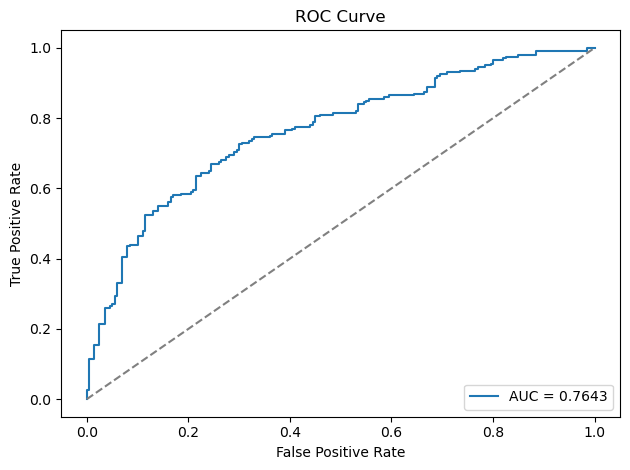

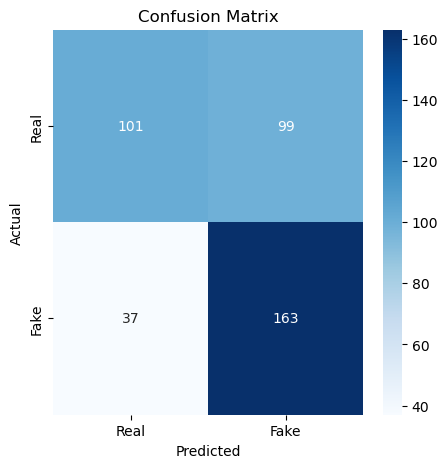

Plots saved: results\roc_curve_sampled_from_train.png results\confusion_matrix_sampled_from_train.png


In [ ]:
# Evaluation helper for test dataset
import os
import torch
import numpy as np
import pandas as pd
import random
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_DIR = "datasets/OpenFake/train"   # sample from train/real and train/fake
SAMPLE_PER_CLASS = 200  
checkpoint_path = "best_wrapped_model.pt"  
BATCH_SIZE = 16
NUM_WORKERS = 0  # Windows-safe
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

# Transforms (same as in training)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Collect and sample from train folders
random.seed(42)
real_dir = os.path.join(TRAIN_DIR, "real")
fake_dir = os.path.join(TRAIN_DIR, "fake")
real_paths = [os.path.join(real_dir, fn) for fn in os.listdir(real_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]
fake_paths = [os.path.join(fake_dir, fn) for fn in os.listdir(fake_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(real_paths) == 0 or len(fake_paths) == 0:
    raise RuntimeError(f"No images found in {real_dir} or {fake_dir}. Check dataset paths.")

n_real = min(SAMPLE_PER_CLASS, len(real_paths))
n_fake = min(SAMPLE_PER_CLASS, len(fake_paths))
print(f"Sampling {n_real} real and {n_fake} fake images from train folders")

sample_real = random.sample(real_paths, n_real)
sample_fake = random.sample(fake_paths, n_fake)

test_paths = sample_real + sample_fake
test_labels = [0] * len(sample_real) + [1] * len(sample_fake)

# Wrap into dataset
test_dataset = OpenFakeDataset(test_paths, test_labels, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

print(f"Test dataset length: {len(test_dataset)} samples (batch_size={BATCH_SIZE})")

# Use existing model object
model = model.to(DEVICE)

if os.path.exists(checkpoint_path):
    state = torch.load(checkpoint_path, map_location=DEVICE)
    # Extract state_dict if present in PyTorch formats
    if isinstance(state, dict):
        if "model_state_dict" in state:
            state_dict = state["model_state_dict"]
        elif "state_dict" in state:
            state_dict = state["state_dict"]
        else:
            state_dict = state

        new_state = {}
        for k, v in state_dict.items():
            nk = k.replace("module.", "") if k.startswith("module.") else k
            new_state[nk] = v
        try:
            model.load_state_dict(new_state, strict=False)
        except Exception as e:
            print("Warning: failed to fully load state_dict into model:", e)
    else:
        try:
            model.load_state_dict(state)
        except Exception as e:
            print("Warning: failed to load checkpoint into model:", e)
    print(f"Loaded checkpoint from {checkpoint_path}")
else:
    print(f"No checkpoint found at {checkpoint_path}; using in-memory model weights")

model.eval()

# Evaluation loop
all_logits = []
all_probs = []
all_preds = []
all_targets = []

softmax = torch.nn.Softmax(dim=1)

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        logits = model(batch_imgs)              
        probs = softmax(logits)               
        preds = logits.argmax(dim=1)           #

        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy()[:, 1])  # prob for class 1
        all_preds.append(preds.cpu().numpy())
        all_targets.append(batch_labels.cpu().numpy())

if len(all_preds) == 0:
    raise RuntimeError("No batches processed by the DataLoader - check sampled paths exist and transforms succeeded")

all_logits = np.concatenate(all_logits, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Metrics
cm = confusion_matrix(all_targets, all_preds)

if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
else:
    tn = fp = fn = tp = 0

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn)>0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Test samples: {len(all_targets)}")
print(f"Accuracy: {accuracy:.4f}, AUC: {roc_auc:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")
print("\nClassification Report:\n", classification_report(all_targets, all_preds, digits=4))

# Save CSV with per-file predictions
df = pd.DataFrame({
    "file": test_paths,
    "target": test_labels,
    "pred": all_preds.tolist(),
    "prob_class1": all_probs.tolist()
})
csv_path = os.path.join(OUT_DIR, "test_predictions_sampled_from_train.csv")
df.to_csv(csv_path, index=False)
print(f"Saved predictions CSV to {csv_path}")

# Plot and save ROC + Confusion Matrix
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
roc_path = os.path.join(OUT_DIR, "roc_curve_sampled_from_train.png")
plt.savefig(roc_path)
plt.show()

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
cm_path = os.path.join(OUT_DIR, "confusion_matrix_sampled_from_train.png")
plt.savefig(cm_path)
plt.show()

print("Plots saved:", roc_path, cm_path)
